<a href="https://colab.research.google.com/github/surojuteja/CNN-project/blob/main/cats_vs_dogs_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐱🐶 Cats vs Dogs Classifier
**Transfer Learning with MobileNetV2 + TensorFlow**

> ⚡ Make sure Runtime → Change runtime type → **GPU (T4)** is selected!


## ✅ Step 1 — Install & Import

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 📦 Step 2 — Download Dataset (Kaggle Dogs vs Cats)

In [2]:
# Downloads the official TF cats_vs_dogs dataset (~800MB)
import tensorflow_datasets as tfds

dataset, info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    as_supervised=True,
    with_info=True
)
train_ds_raw, val_ds_raw, test_ds_raw = dataset

print('Train size:', info.splits['train'].num_examples * 0.8)
print('Classes:', info.features['label'].names)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.79NV08_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
Train size: 18609.600000000002
Classes: ['cat', 'dog']


## 🔧 Step 3 — Preprocessing & Augmentation

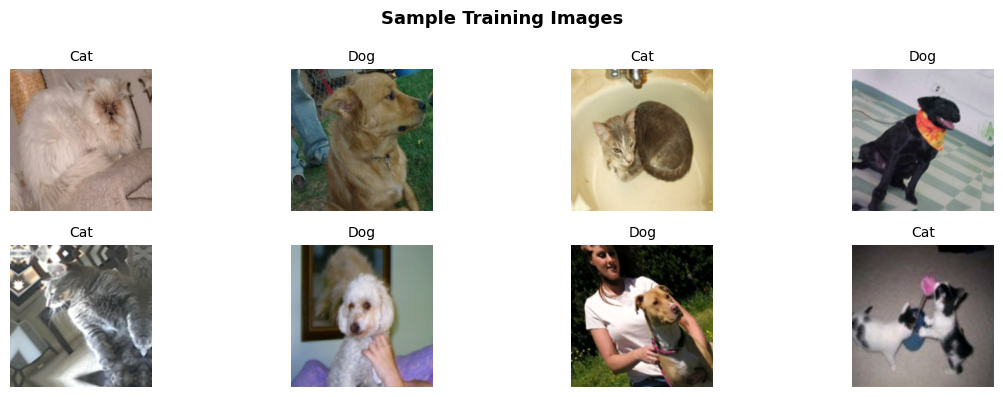

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
], name='augmentation')

def augment(image, label):
    image = augmentation(image, training=True)
    return image, label

train_ds = (train_ds_raw
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .map(augment,    num_parallel_calls=AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (val_ds_raw
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (test_ds_raw
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# Preview samples
CLASS_NAMES = ['Cat', 'Dog']
plt.figure(figsize=(12, 4))
for images, labels in train_ds.take(1):
    for i in range(8):
        plt.subplot(2, 4, i+1)
        plt.imshow(images[i].numpy())
        plt.title(CLASS_NAMES[labels[i].numpy()], fontsize=10)
        plt.axis('off')
plt.suptitle('Sample Training Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🧠 Step 4 — Build Model (MobileNetV2 Transfer Learning)

In [4]:
base_model = MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze backbone

inputs  = tf.keras.Input(shape=(*IMG_SIZE, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(64,  activation='relu')(x)
x       = layers.Dropout(0.2)(x)
outputs = layers.Dense(1,   activation='sigmoid')(x)

model = models.Model(inputs, outputs)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,607,553 (9.95 MB)

 Trainable params: 347,009 (1.32 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

### 🔒 Step 5 — Phase 1: Train the Head (Frozen Backbone)

In [7]:
model.compile(
    optimizer=optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

cb = [
    callbacks.EarlyStopping(patience=4, restore_best_weights=True, monitor='val_accuracy'),
    callbacks.ReduceLROnPlateau(factor=0.5, patience=2, monitor='val_loss', verbose=1),
]

print('🔒 Phase 1: Training head only ...')
history1 = model.fit(
    train_ds,
    epochs=5,
    validation_data=val_ds,
    callbacks=cb
)

🔒 Phase 1: Training head only ...
Epoch 1/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 256s 403ms/step - accuracy: 0.9211 - auc: 0.9776 - loss: 0.1914 - val_accuracy: 0.9824 - val_auc: 0.9979 - val_loss: 0.0499 - learning_rate: 1.0000e-04
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 213s 347ms/step - accuracy: 0.9480 - auc: 0.9894 - loss: 0.1306 - val_accuracy: 0.9798 - val_auc: 0.9981 - val_loss: 0.0524 - learning_rate: 1.0000e-04
Epoch 3/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 213s 348ms/step - accuracy: 0.9529 - auc: 0.9919 - loss: 0.1128 - val_accuracy: 0.9815 - val_auc: 0.9982 - val_loss: 0.0485 - learning_rate: 1.0000e-04
Epoch 4/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 213s 348ms/step - accuracy: 0.9553 - auc: 0.9928 - loss: 0.1067 - val_accuracy: 0.9802 - val_auc: 0.9982 - val_loss: 0.0493 - learning_rate: 1.0000e-04
Epoch 5/5
581/582 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.9547 - auc: 0.9919 - loss: 0.1131
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
582/582 ━━━━━━━━━━━━━━━━━

## 🔓 Step 6 — Phase 2: Fine-tune Top Layers

In [8]:
# Unfreeze top 40 layers of backbone
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(1e-5),  # Much lower LR for fine-tuning!
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

print('🔓 Phase 2: Fine-tuning top 40 backbone layers ...')
history2 = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=cb
)

🔓 Phase 2: Fine-tuning top 40 backbone layers ...
Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 263s 395ms/step - accuracy: 0.9256 - auc: 0.9806 - loss: 0.1787 - val_accuracy: 0.9819 - val_auc: 0.9973 - val_loss: 0.0581 - learning_rate: 1.0000e-05
Epoch 2/10
581/582 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.9404 - auc: 0.9875 - loss: 0.1420
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
582/582 ━━━━━━━━━━━━━━━━━━━━ 224s 366ms/step - accuracy: 0.9443 - auc: 0.9880 - loss: 0.1391 - val_accuracy: 0.9811 - val_auc: 0.9977 - val_loss: 0.0552 - learning_rate: 1.0000e-05
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 222s 365ms/step - accuracy: 0.9492 - auc: 0.9892 - loss: 0.1306 - val_accuracy: 0.9837 - val_auc: 0.9981 - val_loss: 0.0474 - learning_rate: 5.0000e-06
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 262s 364ms/step - accuracy: 0.9529 - auc: 0.9905 - loss: 0.1214 - val_accuracy: 0.9850 - val_auc: 0.9981 - val_loss: 0.0448 - learning_rate: 5.0000e-06
Epoch 5/10
582/

## 📊 Step 7 — Plot Training Curves

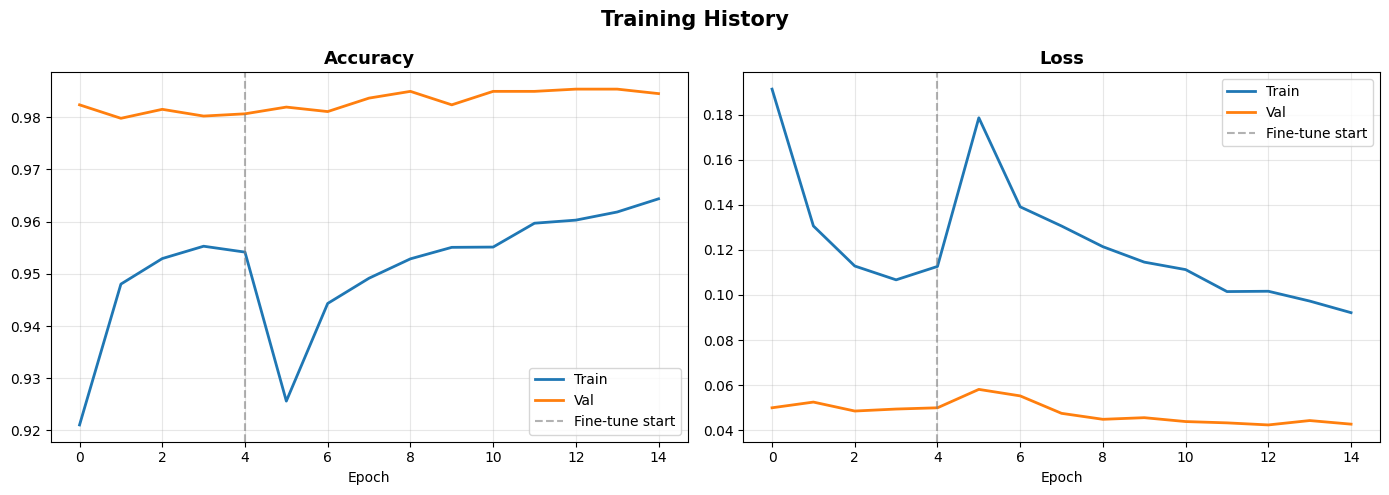

In [9]:
# Merge both phase histories
acc     = history1.history['accuracy']     + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss    = history1.history['loss']         + history2.history['loss']
val_loss= history1.history['val_loss']     + history2.history['val_loss']
phase_boundary = len(history1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, train, val, title in [
    (axes[0], acc, val_acc, 'Accuracy'),
    (axes[1], loss, val_loss, 'Loss')
]:
    ax.plot(train, label='Train', linewidth=2)
    ax.plot(val,   label='Val',   linewidth=2)
    ax.axvline(phase_boundary - 1, color='gray', linestyle='--', alpha=0.6, label='Fine-tune start')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 🧪 Step 8 — Evaluate on Test Set

In [10]:
loss, accuracy, auc = model.evaluate(test_ds, verbose=1)
print(f'\n📊 Test Results')
print(f'   Accuracy : {accuracy*100:.2f}%')
print(f'   AUC      : {auc:.4f}')
print(f'   Loss     : {loss:.4f}')

73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9871 - auc: 0.9985 - loss: 0.0370

📊 Test Results
   Accuracy : 98.71%
   AUC      : 0.9985
   Loss     : 0.0370


## 💾 Step 9 — Save the Model

In [11]:
model.save('cats_vs_dogs_model.h5')
print('✅ Model saved as cats_vs_dogs_model.h5')

# Download to your machine
from google.colab import files
files.download('cats_vs_dogs_model.h5')

✅ Model saved as cats_vs_dogs_model.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 🔮 Step 10 — Predict on a Custom Image

Upload an image to classify:


Saving WhatsApp Image 2025-05-03 at 12.46.27 PM.jpeg to WhatsApp Image 2025-05-03 at 12.46.27 PM.jpeg


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


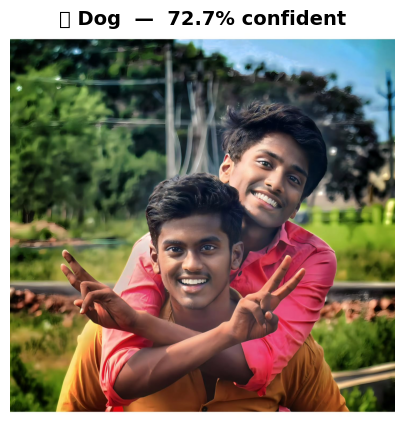

Prediction : 🐶 Dog
Confidence : 72.7%
Raw score  : 0.7272


In [12]:
from google.colab import files
from PIL import Image
import io

print('Upload an image to classify:')
uploaded = files.upload()

for fname, data in uploaded.items():
    img = Image.open(io.BytesIO(data)).convert('RGB')
    img_resized = img.resize((224, 224))
    arr = np.array(img_resized, dtype=np.float32) / 255.0
    arr = np.expand_dims(arr, axis=0)

    score = float(model.predict(arr, verbose=0)[0][0])
    predicted = 1 if score >= 0.5 else 0
    confidence = score if predicted == 1 else (1 - score)
    label = CLASS_NAMES[predicted]
    emoji = '🐶' if predicted == 1 else '🐱'

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f'{emoji} {label}  —  {confidence*100:.1f}% confident', fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

    print(f'Prediction : {emoji} {label}')
    print(f'Confidence : {confidence*100:.1f}%')
    print(f'Raw score  : {score:.4f}')